In [14]:
# !pip install keras-cv==0.6.1 keras-core==0.1.0 tensorflow==2.13.1 tensorflow-datasets==4.9.7

In [15]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import optimizers # type: ignore
import keras_cv
import numpy as np
from keras_cv import bounding_box
import os
from keras_cv import visualization
import tqdm

In [16]:
pretrained_model = keras_cv.models.RetinaNet.from_preset(
    "retinanet_resnet50_pascalvoc", bounding_box_format="xywh"
)

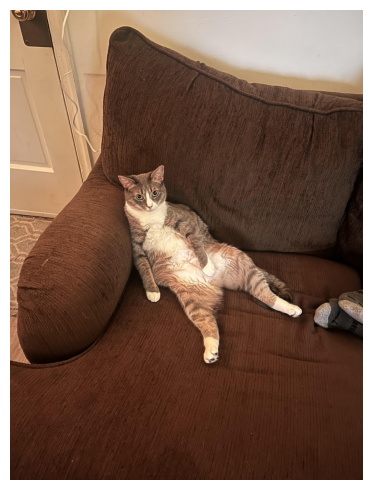

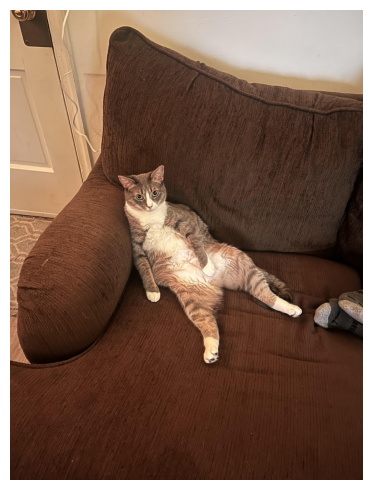

In [17]:
url = 'https://i.redd.it/twpfhcw58xgb1.jpg'
filepath = tf.keras.utils.get_file(origin=url)
image = keras.utils.load_img(filepath)
image = np.array(image)
h, w, c = image.shape
batch = image.reshape(1, h, w, c)

visualization.plot_image_gallery(
    batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    scale=5,
)

In [18]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [19]:
image_batch = inference_resizing(batch)

In [20]:
label_names = [
    "Aeroplane",
    "Bicycle",
    "Bird",
    "Boat",
    "Bottle",
    "Bus",
    "Car",
    "Cat",
    "Chair",
    "Cow",
    "Dining Table",
    "Dog",
    "Horse",
    "Motorbike",
    "Person",
    "Potted Plant",
    "Sheep",
    "Sofa",
    "Train",
    "Tvmonitor",
    "Total",
]
class_mapping = {k: v for k, v in enumerate(label_names)}

c:\Users\lma\AIML-usaii-CV&GenerativeAI\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_204']
Received: inputs=Tensor(shape=(1, 640, 640, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


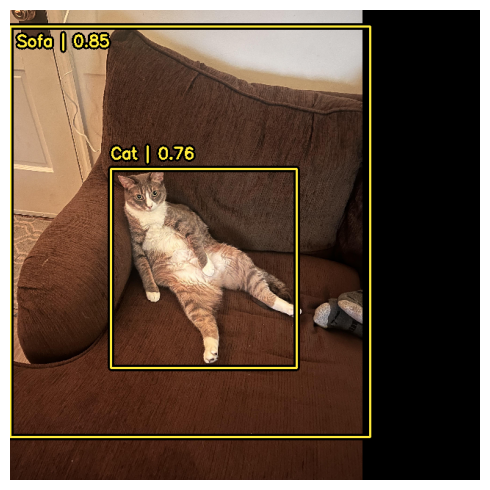

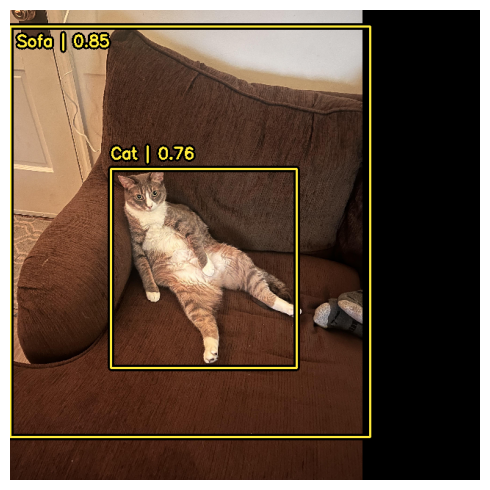

In [21]:
y_pred = pretrained_model.predict(image_batch)
# y_pred is a bounding box Tensor:
# {"classes": ..., boxes": ...}
visualization.plot_bounding_box_gallery(
    images = image_batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    y_pred=y_pred,
    scale=5,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)

In [22]:
y_pred

{'boxes': array([[[ -0.88674927,  22.110687  , 491.30432   , 559.4436    ],
         [137.17673   , 216.78038   , 253.07513   , 270.27313   ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  -1.        ],
         [ -1.        ,  -1.        ,  -1.        ,  

## Non-Max Suppression

In [23]:
url = 'https://archive.org/download/street_202308/street.jpeg'
filepath = tf.keras.utils.get_file(origin=url)
image = keras.utils.load_img(filepath)
image = np.array(image)
h, w, c = image.shape
batch = image.reshape(1, h, w, c)
image_batch = inference_resizing(batch)

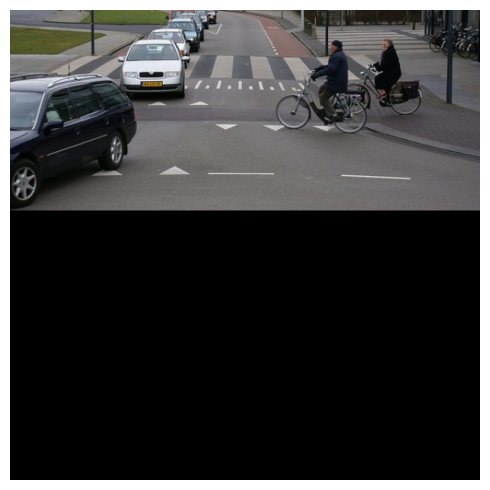

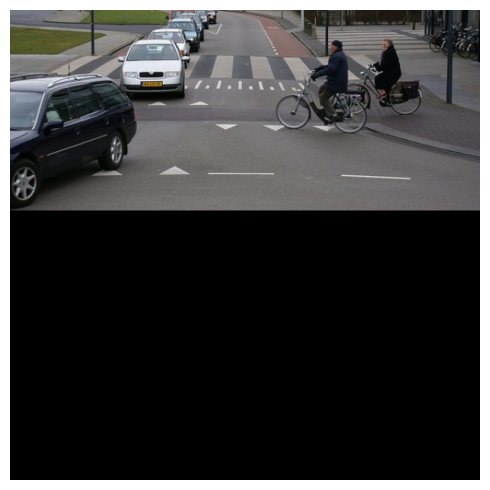

In [24]:
visualization.plot_image_gallery(
    image_batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    scale=5,
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


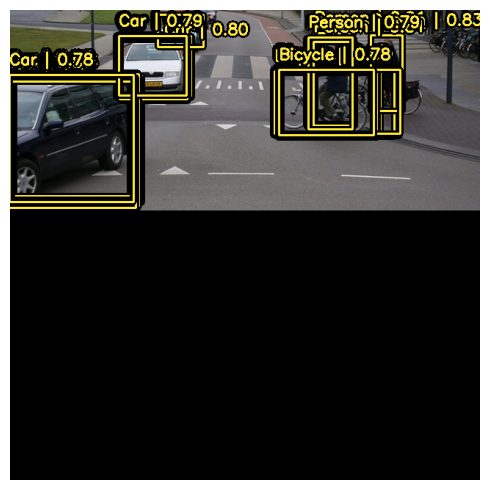

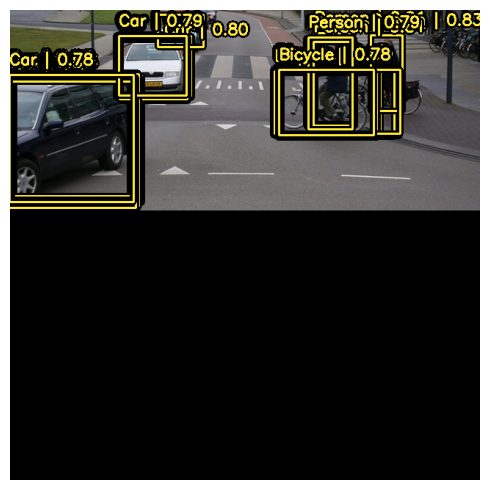

In [25]:
# The following NonMaxSuppression layer is equivalent to disabling the operation
prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    iou_threshold=1.0,
    confidence_threshold=0.0,
)

pretrained_model.prediction_decoder = prediction_decoder

y_pred = pretrained_model.predict(image_batch)

visualization.plot_bounding_box_gallery(
    images = image_batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    y_pred=y_pred,
    scale=5,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


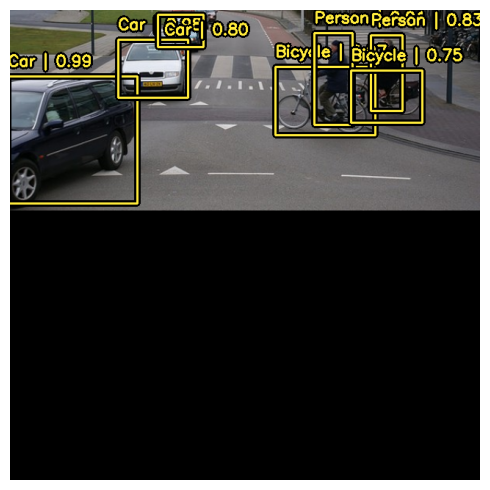

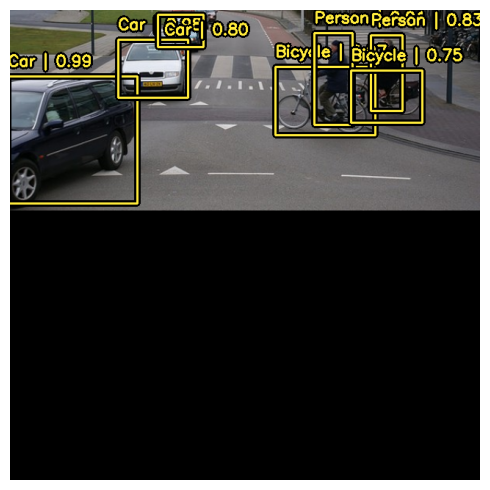

In [26]:
# Try it again!
prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    # Decrease the required threshold to make predictions get pruned out
    iou_threshold=0.2,
    # Tune confidence threshold for predictions to pass NMS
    confidence_threshold=0.7,
)

pretrained_model.prediction_decoder = prediction_decoder

y_pred = pretrained_model.predict(image_batch)

visualization.plot_bounding_box_gallery(
    images = image_batch,
    value_range=(0, 255),
    rows=1,
    cols=1,
    y_pred=y_pred,
    scale=5,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)